# Monte Carlo Tree Search (MCTS) Engine API

A guided tour of the game-agnostic MCTS engine in `mcts_utils.py`:
- `Game`: the 6-method interface any two-player, zero-sum game implements
- `MCTSNode`: one node of the search tree (visit count, value, children)
- `run_mcts()`: selection -> expansion -> rollout -> backpropagation, repeated
- `play_game()` / `evaluate_win_rate()`: compose player functions into games
  and games into statistics

The concrete game used throughout is `TicTacToe` from `game_examples.py`

Part 7 swaps in `ConnectFour` to show that the engine itself never changes.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import logging

import helpers.hdbg as hdbg
import helpers.hnotebook as hnotebook

_LOG = logging.getLogger(__name__)

hdbg.init_logger(verbosity=logging.INFO)
hnotebook.config_notebook()

INFO  > /usr/local/lib/python3.12/site-packages/ipykernel_launcher.py -f /root/.local/share/jupyter/runtime/kernel-5b25afc9-1627-42c9-b40f-cb722abe3df1.json


In [2]:
import helpers.hintrospection as hintros
import research.Implement_MonteCarlo_Tree_Search_and_Alpha_Zero.game_examples as rimtsaazge
import research.Implement_MonteCarlo_Tree_Search_and_Alpha_Zero.mcts_utils as rimtsaazmu

# Part 1: Library Overview

## What problem does `mcts_utils.py` solve?

- Pick a good move in a two-player game without a hand-written evaluation
  function, by running many random-rollout simulations from each candidate
  move and leveraging the law of large numbers
- Balance trying new moves (exploration) against refining promising ones
  (exploitation) via the UCT formula
- Stay game-agnostic: the search code only calls the 6 `Game` methods, so a
  new game plugs in without touching `mcts_utils.py`

## Mental model

| Object | Description | Type / Comments |
|--------|-------------|------------------|
| `Game` | Game-rules interface | ABC with 6 abstract methods |
| `State` | A board position | `Tuple[int, ...]`, game-specific layout |
| `Move` | An action | `int` (cell index, column, ...) |
| `MCTSNode` | One tree node | tracks `state`, `children`, `visit_count`, `value_sum` |
| `run_mcts(game, state)` | Search entry point | returns the most-visited `Move` at the root |
| `random_player(game, state)` | Uniform-random player | matches the player-function signature |
| `make_mcts_player(...)` | MCTS player factory | returns a player function backed by `run_mcts()` |
| `play_game(game, p1, p2)` | Play one game | alternates two player functions to a terminal state |
| `evaluate_win_rate(...)` | Play many games | returns win/draw/loss rates |
| `plot_win_rate_results(...)` | Visualize `evaluate_win_rate()` | bar chart |

# Part 2: `Game`

**Mental model**: `Game` is the contract between a game's rules and the
search code
- anything implementing its 6 methods can be searched by `run_mcts()`
- `TicTacToe` (from `game_examples.py`) is the concrete example used below.

In [38]:
# Link to the interface definition and list its abstract methods.
hintros.print_obj_info(rimtsaazmu.Game)

**Game**
- `apply_move(self, state: Tuple[int, ...], move: int) -> Tuple[int, ...]`: Apply `move` to `state` and return the resulting state...
- `get_current_player(self, state: Tuple[int, ...]) -> int`: Report whose turn it is to move in `state`...
- `get_initial_state(self) -> Tuple[int, ...]`: Build the starting state of a new game...
- `get_legal_moves(self, state: Tuple[int, ...]) -> List[int]`: List the moves available from `state`...
- `get_winner(self, state: Tuple[int, ...]) -> int`: Determine the outcome of a terminal state...
- `is_terminal(self, state: Tuple[int, ...]) -> bool`: Check whether `state` ends the game...
- `render(self, state: Tuple[int, ...]) -> str`: Render `state` as a human-readable board...

https://github.com/gpsaggese/gpsaggese.github.io/blob/gp/research/Implement_MonteCarlo_Tree_Search_and_Alpha_Zero/mcts_utils.py#L55


## Cell 2.1: Construct a `TicTacToe` game and its initial state

In [33]:
# Link to the concrete implementation.
hintros.print_obj_info(rimtsaazge.TicTacToe)

**TicTacToe**
- `apply_move(self, state: Tuple[int, ...], move: int) -> Tuple[int, ...]`: Place the current player's mark at `move`...
- `get_current_player(self, state: Tuple[int, ...]) -> int`: Infer whose turn it is from how many cells are filled...
- `get_initial_state(self) -> Tuple[int, ...]`: Build an empty 3x3 board...
- `get_legal_moves(self, state: Tuple[int, ...]) -> List[int]`: List the empty cells, if any...
- `get_winner(self, state: Tuple[int, ...]) -> int`: Determine the outcome of a finished board...
- `is_terminal(self, state: Tuple[int, ...]) -> bool`: Check whether the board has a winner or is full...
- `render(self, state: Tuple[int, ...]) -> str`: Render the board as 3 rows of space-separated symbols...

https://github.com/gpsaggese/gpsaggese.github.io/blob/gp/research/Implement_MonteCarlo_Tree_Search_and_Alpha_Zero/game_examples.py#L108


In [44]:
game = rimtsaazge.TicTacToe()
state = game.get_initial_state()
print(f"Type: {type(game)}")
# Print the internal state.
print(f"State: {state}")
# Visualize the game.
print(game.render(state))

Type: <class 'research.Implement_MonteCarlo_Tree_Search_and_Alpha_Zero.game_examples.TicTacToe'>
State: (0, 0, 0, 0, 0, 0, 0, 0, 0)
. . .
. . .
. . .


## Cell 2.2: The `Game` methods

In [45]:
legal_moves = game.get_legal_moves(state)
print("Legal moves from the empty board:", legal_moves)

Legal moves from the empty board: [0, 1, 2, 3, 4, 5, 6, 7, 8]


In [46]:
state = game.apply_move(state, 4)
print("\nAfter X plays the center cell:")
print(game.render(state))


After X plays the center cell:
. . .
. X .
. . .


In [47]:
print("is_terminal:", game.is_terminal(state))
print("current player to move:", game.get_current_player(state))

is_terminal: False
current player to move: -1


# Part 3: `MCTSNode`

**Mental model**:
- each `MCTSNode` wraps one `State` plus the running statistics (`visit_count`,
  `value_sum`) the UCT formula needs
- `run_mcts()` grows a tree of these nodes rooted at the state being searched.

## Cell 3.1: Construct a node directly

In [34]:
root = rimtsaazmu.MCTSNode(
    game.get_initial_state(), untried_moves=game.get_legal_moves(state)
)
print(f"Type: {type(root)}")
print("visit_count:", root.visit_count)
print("is_fully_expanded:", root.is_fully_expanded)
print("mean_value (no visits yet):", root.mean_value)

Type: <class 'research.Implement_MonteCarlo_Tree_Search_and_Alpha_Zero.mcts_utils.MCTSNode'>
visit_count: 0
is_fully_expanded: False
mean_value (no visits yet): 0.0


## Cell 3.2: A node's stats update as simulations backpropagate through it

- `run_mcts()` mutates a tree of nodes like `root` in place
- a node visited once with a win backpropagated has `visit_count == 1` and `mean_value == 1.0`.

In [39]:
root.visit_count += 1
root.value_sum += 1.0
print("visit_count:", root.visit_count)
print("mean_value:", root.mean_value)

visit_count: 1
mean_value: 1.0


In [40]:
hintros.print_obj_info(rimtsaazmu.MCTSNode)

**MCTSNode**

https://github.com/gpsaggese/gpsaggese.github.io/blob/gp/research/Implement_MonteCarlo_Tree_Search_and_Alpha_Zero/mcts_utils.py#L135


# Part 4: `run_mcts()`

**Mental model**:
- `run_mcts()` runs `num_simulations` rounds of
  select/expand/rollout/backpropagate from `state`
- then returns the root child with the highest visit count.

## Cell 4.1: Find an immediate winning move

X already has two in a row; playing the third cell wins immediately.

In [36]:
demo_state = (1, 1, 0, -1, -1, 0, 0, 0, 0)
print(game.render(demo_state))

X X .
O O .
. . .


In [41]:
move = rimtsaazmu.run_mcts(game, demo_state, num_simulations=200)
print("MCTS move:", move)

MCTS move: 2


## Cell 4.2: The exploration/simulation-count knobs

In [11]:
print("EXPLORATION_CONSTANT (the `C` in UCT):", rimtsaazmu.EXPLORATION_CONSTANT)
print("DEFAULT_NUM_SIMULATIONS:", rimtsaazmu.DEFAULT_NUM_SIMULATIONS)

EXPLORATION_CONSTANT (the `C` in UCT): 1.4142135623730951
DEFAULT_NUM_SIMULATIONS: 500


In [12]:
hintros.print_obj_info(rimtsaazmu.run_mcts)

- `run_mcts(game: research.Implement_MonteCarlo_Tree_Search_and_Alpha_Zero.mcts_utils.Game, state: Tuple[int, ...], *, num_simulations: int = 500) -> int`  
  Run MCTS from `state` and return the most-visited move at the root...

https://github.com/gpsaggese/gpsaggese.github.io/blob/gp/research/Implement_MonteCarlo_Tree_Search_and_Alpha_Zero/mcts_utils.py#L294


# Part 5: Composing players and games

**Mental model**: a "player" is any `(game, state) -> Move` function;
`play_game()` alternates two of them until the board is terminal, so a
uniformly-random player and an MCTS-backed player are interchangeable.

## Cell 5.1: `random_player` and `make_mcts_player()`

In [13]:
mcts_player = rimtsaazmu.make_mcts_player(num_simulations=100)
print("random_player move:", rimtsaazmu.random_player(game, state))
print("mcts_player move:", mcts_player(game, state))

random_player move: 0
mcts_player move: 1


## Cell 5.2: `play_game()` runs one full game

In [14]:
winner, history = rimtsaazmu.play_game(
    game, mcts_player, rimtsaazmu.random_player
)
print("winner:", winner)
print("number of states visited:", len(history))
print(game.render(history[-1]))

winner: 1
number of states visited: 6
. X .
O X .
O X .


In [15]:
hintros.print_obj_info(rimtsaazmu.play_game)

- `play_game(game: research.Implement_MonteCarlo_Tree_Search_and_Alpha_Zero.mcts_utils.Game, player1: Callable[[research.Implement_MonteCarlo_Tree_Search_and_Alpha_Zero.mcts_utils.Game, Tuple[int, ...]], int], player2: Callable[[research.Implement_MonteCarlo_Tree_Search_and_Alpha_Zero.mcts_utils.Game, Tuple[int, ...]], int], *, verbose: bool = False) -> Tuple[int, List[Tuple[int, ...]]]`  
  Play one full game between two players, alternating moves...

https://github.com/gpsaggese/gpsaggese.github.io/blob/gp/research/Implement_MonteCarlo_Tree_Search_and_Alpha_Zero/mcts_utils.py#L370


# Part 6: Evaluation API

**Mental model**: `evaluate_win_rate()` calls `play_game()` many times and
reports outcome rates; `plot_win_rate_results()` turns that dict into a bar
chart.

## Cell 6.1: Win rate over 100 games

In [16]:
results = rimtsaazmu.evaluate_win_rate(
    game, mcts_player, rimtsaazmu.random_player, num_games=100
)
print(results)

100%|██████████| 100/100 [00:00<00:00, 109.68it/s]

{'num_games': 100.0, 'win_rate': 0.99, 'loss_rate': 0.0, 'draw_rate': 0.01}


## Cell 6.2: Plot the results

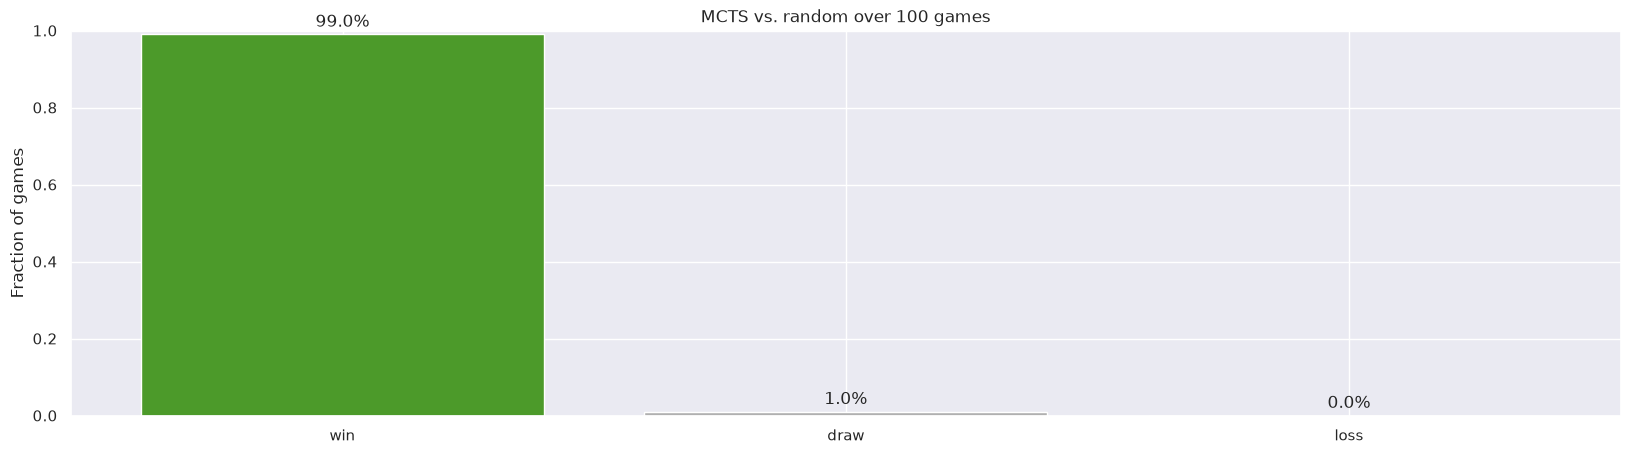

In [17]:
rimtsaazmu.plot_win_rate_results(results)

# Part 7: Swapping in a different `Game`

**Mental model**: none of Parts 3-6 mentioned `TicTacToe` by name; the same
`run_mcts()` / `play_game()` code works unchanged against `ConnectFour`,
because both only go through the `Game` interface.

## Cell 7.1: The same engine, a different game

In [18]:
connect_four = rimtsaazge.ConnectFour()
cf_state = connect_four.get_initial_state()
cf_mcts_player = rimtsaazmu.make_mcts_player(num_simulations=100)

move = rimtsaazmu.run_mcts(connect_four, cf_state, num_simulations=100)
print("MCTS move on an empty Connect Four board (column):", move)

winner, history = rimtsaazmu.play_game(
    connect_four, cf_mcts_player, rimtsaazmu.random_player
)
print("\nwinner:", winner)
print(connect_four.render(history[-1]))

MCTS move on an empty Connect Four board (column): 1

winner: 1
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . O .
. . . . . O .
. . X X X X O


# Part 8: Summary

## Summary: The Mental Model

- **`Game`**: the 6-method contract (`get_initial_state`, `get_legal_moves`,
  `apply_move`, `is_terminal`, `get_winner`, `get_current_player`, `render`)
  that decouples game rules from search
- **`MCTSNode`**: one search-tree node; tracks `state`, `children`,
  `visit_count`, `value_sum`
- **`run_mcts(game, state)`**: the search loop; returns the most-visited
  root move after `num_simulations` rounds of select/expand/rollout/backprop
- **`random_player` / `make_mcts_player(...)`**: player functions with the
  `(game, state) -> Move` signature `play_game()` expects
- **`play_game(...)` / `evaluate_win_rate(...)`**: compose player functions
  into single games, then into aggregate statistics
- Swapping `TicTacToe` for `ConnectFour` (Part 7) needed zero changes to
  `mcts_utils.py`: that is the payoff of the `Game` interface